# Trabalho de Introdução a Ciência de Dados - G13

In [1]:
%matplotlib inline
# Importar bibliotecas
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'svg'


In [2]:
# Carrega a sheet do arquivo excel
df_all = pd.read_excel("Dados_Sneakers_World3.xlsx", sheet_name='Sales')

In [3]:
# verifica se na base existem linhas duplicadas
df_all.duplicated().sum()

np.int64(0)

In [4]:
# Cria DF só com as variáveis de interesse
df = df_all[['Sales', 'Quantity']]

# Verifica se existem valores nulos
df.isnull().sum()

Sales       0
Quantity    0
dtype: int64

In [5]:
# Verifica se existem NaN
df.isna().sum()

Sales       0
Quantity    0
dtype: int64

In [6]:
# Calcula Media, media e Moda das variáveis Sales e Quantity
medidas_posicao = pd.DataFrame({
    'Media': df.mean(),
    'Mediana': df.median(),
    'Moda': df.mode().iloc[0]
})
print(medidas_posicao)

               Media  Mediana    Moda
Sales     166.137680   85.671  50.946
Quantity    3.529076    3.000   1.000


In [7]:
# Calcula Variancia, desvio padrão e coeficiente de variação de Sales e Quantity
medidas_dispersao = pd.DataFrame({
    'Variancia': df.var(),
    'Desvio Padrão': df.std(),
    'CV (%)': (df.std() / df.mean()) * 100
})
print(medidas_dispersao)

             Variancia  Desvio Padrão      CV (%)
Sales     50013.376443     223.636706  134.609263
Quantity      9.223665       3.037049   86.057907


In [8]:
# Macro definições
ROTULOS = ['Sales', 'Quantity' ]
CORES = ['lightgreen','lightblue' ]
FIG_SIZE = (10,6)

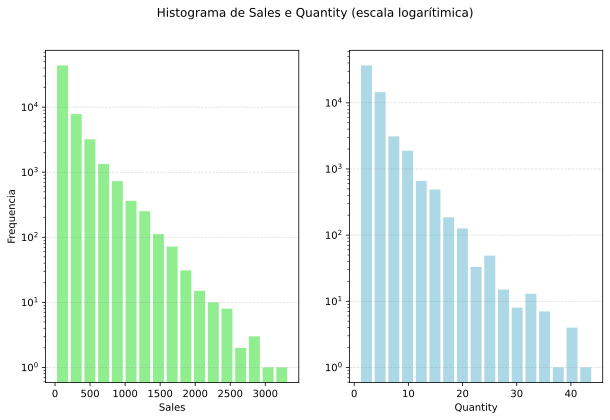

In [9]:
# Histograma
# cria figura e subplots
fig, axs = plt.subplots(1, 2, figsize=FIG_SIZE)

# estiliza para todas os subplots
for i in range(2):
    axs[i].hist(df.iloc[:,i], bins='sturges', color=CORES[i], rwidth=0.8, log=True)
    axs[i].set_xlabel(ROTULOS[i]) # define o rótulo da séria
    axs[i].set_facecolor('white') # cor de fundo de gráfico
    axs[i].grid(color='gray', linestyle='--', linewidth=0.7, axis='y', alpha=0.3)
    

axs[0].set_ylabel("Frequencia") # título do eixo Y apenas no gráfico da esquerda

fig.suptitle("Histograma de Sales e Quantity (escala logarítimica)") # título da figura

plt.show()

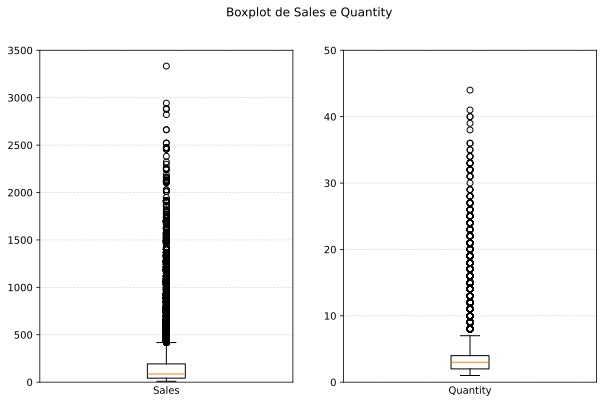

In [10]:
# Boxplots
# cria figura e subplots
fig, axs = plt.subplots(1, 2,  figsize=FIG_SIZE)

# estiliza para todas os subplots
for i in range(2):
    
    axs[i].boxplot(df.iloc[:,i])
    axs[i].set_xlabel(ROTULOS[i]) # define o rótulo da séria
    axs[i].set_facecolor('white') # cor de fundo de gráfico
    axs[i].grid(color='gray', linestyle='--', linewidth=0.7, axis='y', alpha=0.3)
    axs[i].set_xticks([])
    
# Ajusta as escalas verticais de cada boxplot
axs[0].set_ylim([0, 3500]) #   
axs[1].set_ylim([0, 50])

fig.suptitle("Boxplot de Sales e Quantity") # título da figura

plt.show()